In [2]:
from tensorflow import keras
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
train_images = glob.glob('../Data/fingers/fingers/train/*.png')
test_images = glob.glob('../Data/fingers/fingers/test/*.png')

In [4]:
train_images[:5]

['../Data/fingers/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [5]:
test_images[:5]

['../Data/fingers/fingers/test\\000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png',
 '../Data/fingers/fingers/test\\001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png',
 '../Data/fingers/fingers/test\\0027029b-4c3c-4785-bc1b-b8141331a108_3R.png',
 '../Data/fingers/fingers/test\\004599fb-c735-4ff3-a969-342dda319382_5L.png',
 '../Data/fingers/fingers/test\\00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png']

In [6]:
print(len(train_images))
print(len(test_images))

18000
3600


In [7]:
train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images): # 알파벳 정렬
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS) # 파일이 손상되지 않게 줄인다
    train_input.append(imgResize)
    train_target.append(image[-6:-4])

# test data
for image in sorted(test_images): # 알파벳 정렬
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS) # 파일이 손상되지 않게 줄인다
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

# Target Data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


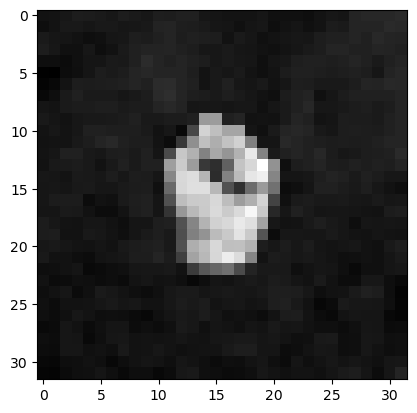

In [8]:
# train 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

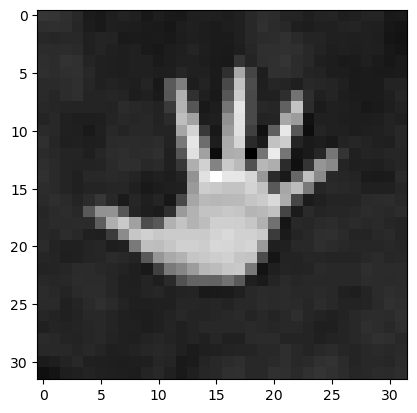

In [9]:
# test 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

In [10]:
import numpy as np

In [11]:
# train data 만들기 (18000 * 32 * 32)
tempData = np.zeros(
    18000 * 32 * 32,
    dtype=np.int32
).reshape(18000, 32, 32)

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1
train_input = tempData.copy()

In [12]:
# test data 만들기 (3600 * 32 * 32)
tempData = np.zeros(
    3600 * 32 * 32,
    dtype=np.int32
).reshape(3600, 32, 32)

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1
test_input = tempData.copy()

In [13]:
# 배열 크기 확인
print(train_input.shape)
print(test_input.shape)

(18000, 32, 32)
(3600, 32, 32)


In [14]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11
}

In [15]:
# train_target을 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [16]:
# test_target을 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [17]:
# Target도 numpy 배열로 변경
train_target = np.array(train_target)

In [18]:
test_target = np.array(test_target)

In [22]:
train_input.shape

(18000, 32, 32)

In [23]:
train_scaled = train_input.reshape(-1, 32, 32, 1)
train_scaled.shape

(18000, 32, 32, 1)

In [24]:
from sklearn.model_selection import train_test_split


train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [25]:
print(train_scaled.shape, val_scaled.shape)

(14400, 32, 32, 1) (3600, 32, 32, 1)


In [40]:
model = keras.Sequential()

In [41]:
# 합성곱 (CNN)
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(32, 32, 1)
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

c:\Users\tuxca\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same',
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

#### Dense

In [43]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(50, activation='relu'))
# model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(12, activation='softmax'))

In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,178 (1.66 MB)

 Trainable params: 434,178 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# model compile

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_finger_cnn.keras')
earlystopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=8,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, earlystopping_cb]
)

Epoch 1/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9353 - loss: 0.5201 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 2/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 1.0000 - loss: 4.2603e-04 - val_accuracy: 1.0000 - val_loss: 2.4923e-04
Epoch 3/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 1.0000 - loss: 8.0061e-05 - val_accuracy: 1.0000 - val_loss: 1.0515e-04
Epoch 4/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 1.0000 - loss: 3.7208e-05 - val_accuracy: 1.0000 - val_loss: 5.1010e-05
Epoch 5/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 1.0000 - loss: 2.1273e-05 - val_accuracy: 1.0000 - val_loss: 3.5343e-05
Epoch 6/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 1.0000 - loss: 1.1123e-05 - val_accuracy: 1.0000 - val_loss: 2.5067e-05
Epoch 7/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 1.0000 - loss: 6.9774e-06 - val_accuracy: 1.0000 - val_loss: 1.7073e-05
Epoch 8/8
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step -

In [46]:
model.evaluate(train_scaled, train_target)

450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 3.2212e-06


[3.221232418582076e-06, 1.0]

In [47]:
model.evaluate(val_scaled, val_target)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 1.4114e-05


[1.4114095392869785e-05, 1.0]

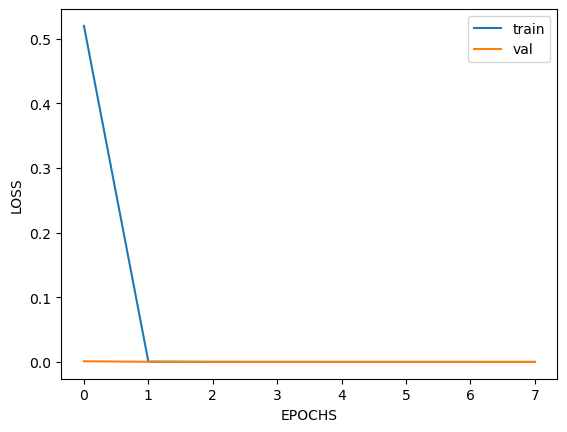

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend(['train', 'val'])
plt.show()

In [51]:
val_scaled[0]

array([[[51],
        [57],
        [58],
        ...,
        [57],
        [47],
        [47]],

       [[51],
        [55],
        [58],
        ...,
        [56],
        [48],
        [45]],

       [[59],
        [58],
        [60],
        ...,
        [54],
        [48],
        [45]],

       ...,

       [[39],
        [42],
        [41],
        ...,
        [49],
        [43],
        [48]],

       [[46],
        [44],
        [42],
        ...,
        [48],
        [44],
        [40]],

       [[47],
        [48],
        [48],
        ...,
        [44],
        [42],
        [40]]], shape=(32, 32, 1), dtype=int32)

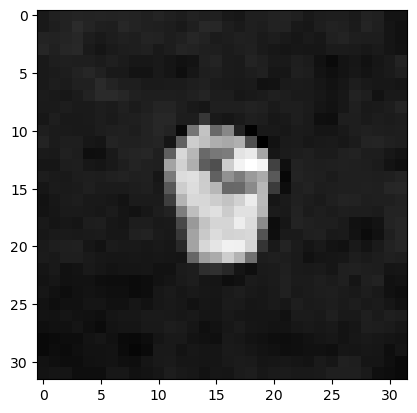

In [52]:
plt.imshow(
    val_scaled[0].reshape(32, 32),
    cmap='gray'
)

plt.show()

In [59]:
val_scaled.shape

(3600, 32, 32, 1)

In [69]:
pred = model.predict(val_scaled[1:2])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


array([[3.2119955e-24, 1.8472053e-12, 1.5007380e-10, 1.7587284e-14,
        1.0000000e+00, 3.3736480e-10, 1.0113208e-15, 7.0489663e-11,
        3.8895783e-12, 2.6977533e-17, 6.1961969e-09, 1.2988155e-13]],
      dtype=float32)

In [70]:
finger_count = [
    '오른손 0',
    '오른손 1',
    '오른손 2',
    '오른손 3',
    '오른손 4',
    '오른손 5',
    '왼손 0',
    '왼손 1',
    '왼손 2',
    '왼손 3',
    '왼손 4',
    '왼손 5'
]

In [71]:
finger_count[np.argmax(pred)]

'오른손 4'

In [72]:
test_input.shape

(3600, 32, 32)

In [73]:
test_scaled = test_input.reshape(-1, 32, 32, 1)
test_scaled.shape

(3600, 32, 32, 1)

In [74]:
model.evaluate(test_scaled, test_target)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 4.4395e-05


[4.439455005922355e-05, 1.0]